# Real-time Communication

In [1]:
import networkx as nx 
from dataXplorer import JupyterClient
from dataXplorer import AnalysisToolkit, SessionManager, TextureGenerator, ProjectFileManager, VisualizerSyncer

In [2]:
# run backend (server) using buildandrun powershell script
client = JupyterClient()

#client.disconnect()

✅ Connected to /main


### OPTIONAL : Create new Project  (if project is not in list)

In [3]:
import pandas as pd

edge_df = pd.read_csv(
    'temp-files/PPI_joel/human_ppi.tsv',
    sep = '\t',
    #compression = 'gzip',
    header = None,
    names = ['A', 'B']
)
edges = []
for _, row in edge_df.iterrows():
    edges.append(
        (row.A, row.B)
    )

G = nx.Graph()
G.add_edges_from(edges)

# use only the largest connected component
def largest_connected_component(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return largest_cc

# use only the largest connected component
lcc_nodes = largest_connected_component(G)
G = nx.induced_subgraph(G, lcc_nodes)

KeyboardInterrupt: 

In [ ]:
G.nodes()

nodenames = list(G.nodes())

In [ ]:
#number of nodes
n_nodes = G.number_of_nodes()
print(f"Number of nodes in the PPI network: {n_nodes}")
#number of edges
n_edges = G.number_of_edges()
print(f"Number of edges in the PPI network: {n_edges}")


In [ ]:
G.graph['projectname'] = "PPI_joel_daniel_aryan"
G.graph['info'] = "."

#posG = nx.spring_layout(G, dim=3)
posG = nx.random_layout(G, dim=3, seed=42)
posG_3D = dict(zip(G.nodes(),[i.tolist() for i in posG.values()])) # 3D positions
nx.set_node_attributes(G, posG_3D, 'pos')

blueblue = "#0739ff"
d_nodecolors_hex = dict(zip(G.nodes(),[blueblue]*len(G.nodes()))) 
nx.set_node_attributes(G, d_nodecolors_hex, 'nodecolor')

lightblue = "#001d91"
l_linkcolors_hex = lightblue
nx.set_edge_attributes(G, l_linkcolors_hex, 'linkcolor')

import nx2json as nx2j 
nx2j.create_project(G)

### Access Project list and select one by ID

In [3]:
# see if new project is in projectlist
import GlobalData as GD

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, 'CDK5'),
 (1, 'CircLadderGraph-xsmall'),
 (2, 'diffusion'),
 (3, 'JSON_autocore'),
 (4, 'JSON_barbellgraph'),
 (5, 'JSON_Zachary'),
 (6, 'Microplastics_HumanHealth'),
 (7, 'Pesticides_HumanHealth'),
 (8, 'PG_NEW'),
 (9, 'Powergrid_Europe'),
 (10, 'PPI_brain_infarction'),
 (11, 'PPI_joel_daniel_aryan'),
 (12, 'PPI_networkcartoGRAPHs'),
 (13, 'Realtime-project'),
 (14, 'Sphere_Torus'),
 (15, 'Teapot'),
 (16, 'test'),
 (17, 'TheMandelbulb_edges'),
 (18, 'XX')]

In [4]:
# select a project to work with
sel_id = 11
sel_name = allprojects_updated[sel_id][1]

# load the project data
session = SessionManager(sel_id, sel_name, client)
session.load_graph_from_project()
session.reload_project()

# initialize 
file_mgr = ProjectFileManager(session)
tex_gen = TextureGenerator(session)
syncer = VisualizerSyncer(session)

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


In [5]:
G = session.load_graph_from_project()

# get nodenames from node attributes
nodenames_session = [data.get("name") for _, data in G.nodes(data=True)]
nodenames_session = [name for name in nodenames_session if name is not None]

# rename nodes back to original names
mapping = dict(zip(G.nodes(), nodenames_session))
G = nx.relabel_nodes(G, mapping)
G.nodes()

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


NodeView(('CIC', 'GTPBP3', 'KLF5', 'TRIM22', 'SOX15', 'ELF4', 'ELK3', 'SETD2', 'SOX6', 'YWHAQ', 'FOXQ1', 'SOX5', 'PAX7', 'SP7', 'HNF4A', 'KLHL22', 'ERG', 'S100P', 'TEAD1', 'PICK1', 'NFIX', 'PAX6', 'SOX17', 'TLX2', 'IRF8', 'RAVER1', 'GABPB1', 'NFIC', 'YWHAB', 'GATA2', 'LHX3', 'FOS', 'EN1', 'MAD2L1', 'KLF3', 'TBXT', 'TLX3', 'PAX9', 'NFYC', 'TBR1', 'SEC62', 'LHX6', 'CENPJ', 'PRDM1', 'HNF1A', 'SOX9', 'PYCR2', 'TLX1', 'CSNK2B', 'YWHAZ', 'RAD50', 'VSX1', 'IRF4', 'LHX4', 'PAX8', 'ZBTB18', 'GATA3', 'FOXL1', 'PLK1', 'YWHAE', 'MYB', 'ESR1', 'POLR1H', 'GOLGA2', 'PAX2', 'AR', 'GCM1', 'LHX2', 'FEV', 'SOX2', 'FOXK2', 'YWHAG', 'SOX10', 'HNF1B', 'ATXN1', 'KLF12', 'KLF15', 'NFIA', 'EYA2', 'YWHAH', 'NFIB', 'KLF8', 'PRPF3', 'PPP1R18', 'ETFRF1', 'RASL10B', 'MRPL21', 'DPPA4', 'SERTAD3', 'GPR45', 'MBD3L1', 'GNE', 'TARDBP', 'PYCR1', 'AGR2', 'RALY', 'PIKFYVE', 'MEOX2', 'MESD', 'INCA1', 'BEND7', 'PTAFR', 'MGST3', 'RCN1', 'COPS5', 'YARS2', 'SPINT2', 'IMMP2L', 'ZNF774', 'CAPN3', 'RAMP2', 'PDK1', 'KLK14', 'SINHCA

### Manipulate node colors / positions / link colors 

In [6]:
# initialize analysis toolkit
tools = AnalysisToolkit(session, tex_gen, syncer, file_mgr)

In [7]:
import pandas as pd
# read gene list from csv
symbol_pep_3 = pd.read_csv('temp-files/PPI_joel/symbol_pep_3.csv', header=None)[0].tolist()
symbol_pep_11 = pd.read_csv('temp-files/PPI_joel/symbol_pep_11.csv', header=None)[0].tolist()
symbol_pep_33 = pd.read_csv('temp-files/PPI_joel/symbol_pep_33.csv', header=None)[0].tolist()
symbol_pep_54 = pd.read_csv('temp-files/PPI_joel/symbol_pep_54.csv', header=None)[0].tolist()
symbol_pep_63 = pd.read_csv('temp-files/PPI_joel/symbol_pep_63.csv', header=None)[0].tolist()
symbol_pep_66 = pd.read_csv('temp-files/PPI_joel/symbol_pep_66.csv', header=None)[0].tolist()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

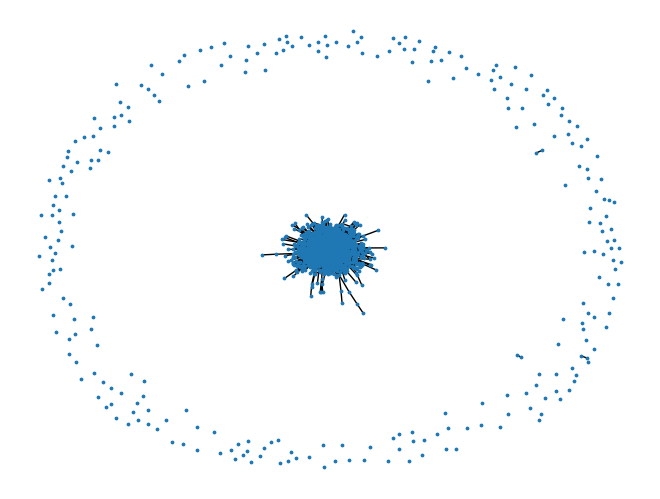

✅ Connected to /main


In [12]:
nodelist = symbol_pep_3
#temp_nodelist = ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7', 'node8']

tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, color = (255,0,255,200))

In [17]:
session.reload_project() # to get back to initial state of project (incl. initial layout)

✅ Connected to /main
✅ Connected to /main


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

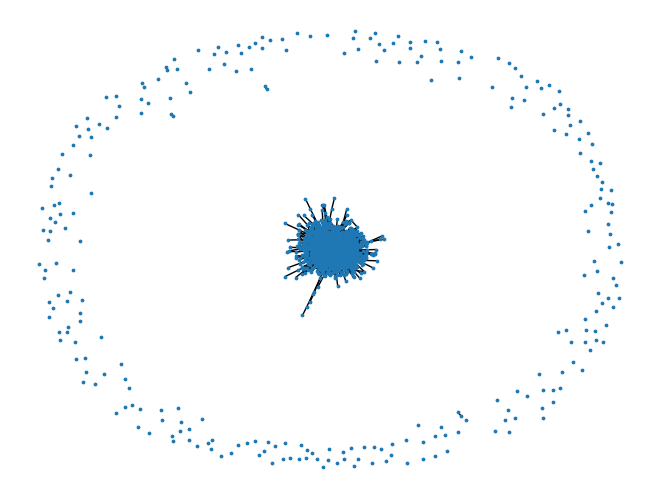

In [18]:
nodelist = symbol_pep_3
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=True, color = (255,255,0,200))